2025/10/08 11:21:38 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: OriginalPSO(epoch=5, pop_size=10, c1=2.05, c2=2.05, w=0.4)


Optimizing Random Forest using PSO...


2025/10/08 11:21:53 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 1, Current best: -0.7375086042587663, Global best: -0.7375086042587663, Runtime: 7.10633 seconds
2025/10/08 11:21:59 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 2, Current best: -0.7375086042587663, Global best: -0.7375086042587663, Runtime: 6.32610 seconds
2025/10/08 11:22:05 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 3, Current best: -0.7375086042587663, Global best: -0.7375086042587663, Runtime: 5.86587 seconds
2025/10/08 11:22:10 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 4, Current best: -0.7375086042587663, Global best: -0.7375086042587663, Runtime: 4.91016 seconds
2025/10/08 11:22:14 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 5, Current best: -0.7375086042587663, Global best: -0.7375086042587663, Runtime: 4.20429 seconds
2025/10/08 11:22:14 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: BaseGA(e

PSO Accuracy: 0.7375
PSO Best Params: {'n_estimators': 55, 'max_depth': 18, 'min_samples_split': 15}

Optimizing Random Forest using GA...


2025/10/08 11:22:25 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 1, Current best: -0.7361406203018261, Global best: -0.7361406203018261, Runtime: 5.86557 seconds
2025/10/08 11:22:31 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 2, Current best: -0.7361406203018261, Global best: -0.7361406203018261, Runtime: 6.55706 seconds
2025/10/08 11:22:40 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 3, Current best: -0.7365959937080193, Global best: -0.7365959937080193, Runtime: 8.26103 seconds
2025/10/08 11:22:48 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 4, Current best: -0.7365959937080193, Global best: -0.7365959937080193, Runtime: 8.76741 seconds
2025/10/08 11:22:56 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 5, Current best: -0.7365959937080193, Global best: -0.7365959937080193, Runtime: 7.99033 seconds
2025/10/08 11:22:56 PM, INFO, mealpy.swarm_based.BA.OriginalBA: Origin

GA Accuracy: 0.7366
GA Best Params: {'n_estimators': 110, 'max_depth': 9, 'min_samples_split': 11}

Optimizing Random Forest using Bat...


2025/10/08 11:23:15 PM, INFO, mealpy.swarm_based.BA.OriginalBA: >>>Problem: P, Epoch: 1, Current best: -0.737052609606453, Global best: -0.737052609606453, Runtime: 13.45050 seconds
2025/10/08 11:23:31 PM, INFO, mealpy.swarm_based.BA.OriginalBA: >>>Problem: P, Epoch: 2, Current best: -0.737052609606453, Global best: -0.737052609606453, Runtime: 16.26594 seconds
2025/10/08 11:23:48 PM, INFO, mealpy.swarm_based.BA.OriginalBA: >>>Problem: P, Epoch: 3, Current best: -0.737052609606453, Global best: -0.737052609606453, Runtime: 17.29586 seconds
2025/10/08 11:24:05 PM, INFO, mealpy.swarm_based.BA.OriginalBA: >>>Problem: P, Epoch: 4, Current best: -0.737052609606453, Global best: -0.737052609606453, Runtime: 16.79957 seconds
2025/10/08 11:24:21 PM, INFO, mealpy.swarm_based.BA.OriginalBA: >>>Problem: P, Epoch: 5, Current best: -0.737052609606453, Global best: -0.737052609606453, Runtime: 15.80990 seconds


Bat Accuracy: 0.7371
Bat Best Params: {'n_estimators': 60, 'max_depth': 18, 'min_samples_split': 16}



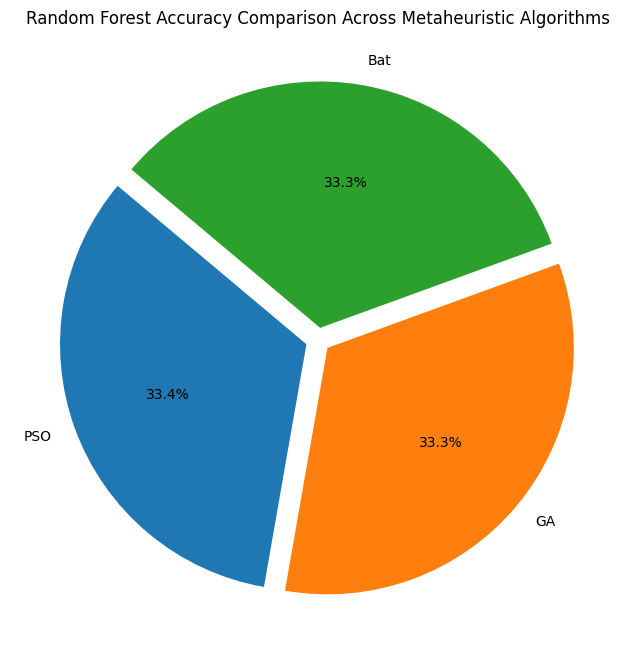

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
from mealpy.swarm_based import PSO
from mealpy.evolutionary_based import GA
from mealpy.swarm_based.BA import OriginalBA
import mealpy.swarm_based.BA as bat_algorithm
from mealpy.utils.problem import FloatVar
import warnings

warnings.filterwarnings('ignore')

# ----------------------------
# Load dataset
# ----------------------------
def load_data():
    amazon = pd.read_csv("amazon_cells_labelled.txt", sep="\t", header=None, names=["text", "label"])
    imdb   = pd.read_csv("imdb_labelled.txt", sep="\t", header=None, names=["text", "label"])
    yelp   = pd.read_csv("yelp_labelled.txt", sep="\t", header=None, names=["text", "label"])
    
    df = pd.concat([amazon, imdb, yelp], axis=0)
    
    from sklearn.feature_extraction.text import TfidfVectorizer
    vectorizer = TfidfVectorizer(stop_words="english", max_features=1000)
    X = vectorizer.fit_transform(df["text"]).toarray()
    y = df["label"].values
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = load_data()

# ----------------------------
# Random Forest Objective Function
# ----------------------------
def rf_objective_function(solution):
    n_estimators = int(solution[0])
    max_depth = int(solution[1])
    min_samples_split = int(solution[2])
    
    try:
        # Ensure valid hyperparameters
        if n_estimators < 1:
            n_estimators = 10
        if max_depth < 1:
            max_depth = None
        if min_samples_split < 2:
            min_samples_split = 2
            
        rf = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            random_state=42
        )
        scores = cross_val_score(rf, X_train, y_train, cv=3, scoring='accuracy')
        fitness = -np.mean(scores)  # Minimize negative accuracy
    except:
        fitness = 1.0
    
    return fitness

# ----------------------------
# Random Forest Problem Definition
# ----------------------------
rf_problem = {
    "bounds": [
        FloatVar(lb=10, ub=200, name="n_estimators"),         # Number of trees
        FloatVar(lb=1, ub=20, name="max_depth"),              # Max depth
        FloatVar(lb=2, ub=20, name="min_samples_split")       # Min samples to split
    ],
    "minmax": "min",
    "obj_func": rf_objective_function
}

# ----------------------------
# Run All Algorithms
# ----------------------------
algorithms = {
    "PSO": PSO.OriginalPSO(epoch=5, pop_size=10),
    "GA": GA.BaseGA(epoch=5, pop_size=10),
    "Bat": bat_algorithm.OriginalBA(epoch=5, pop_size=10)
}

results = {}

for name, optimizer in algorithms.items():
    print(f"Optimizing Random Forest using {name}...")
    best_agent = optimizer.solve(rf_problem)
    best_solution = best_agent.solution
    best_fitness = -best_agent.target.fitness
    
    best_params = {
        'n_estimators': int(best_solution[0]),
        'max_depth': int(best_solution[1]),
        'min_samples_split': int(best_solution[2])
    }
    
    results[name] = best_fitness
    print(f"{name} Accuracy: {best_fitness:.4f}")
    print(f"{name} Best Params: {best_params}\n")

# ----------------------------
# Combined Pie Chart
# ----------------------------
plt.figure(figsize=(8, 8))
plt.pie(results.values(), labels=results.keys(), autopct='%1.1f%%', startangle=140, explode=[0.05]*len(results))
plt.title("Random Forest Accuracy Comparison Across Metaheuristic Algorithms")
plt.show()


In [3]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import warnings

# ----------------------------
# Mealpy algorithm imports (latest structure)
# ----------------------------
from mealpy.swarm_based import PSO, BA, CSO, FA, ABC
from mealpy.evolutionary_based import GA
from mealpy.swarm_based.ACOR import OriginalACO
from mealpy.utils.problem import FloatVar

warnings.filterwarnings('ignore')

# ----------------------------
# Load dataset
# ----------------------------
def load_data():
    amazon = pd.read_csv("amazon_cells_labelled.txt", sep="\t", header=None, names=["text", "label"])
    imdb   = pd.read_csv("imdb_labelled.txt", sep="\t", header=None, names=["text", "label"])
    yelp   = pd.read_csv("yelp_labelled.txt", sep="\t", header=None, names=["text", "label"])
    
    df = pd.concat([amazon, imdb, yelp], axis=0)
    from sklearn.feature_extraction.text import TfidfVectorizer
    vectorizer = TfidfVectorizer(stop_words="english", max_features=1000)
    X = vectorizer.fit_transform(df["text"]).toarray()
    y = df["label"].values
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = load_data()

# ----------------------------
# Random Forest Objective Function
# ----------------------------
def rf_objective_function(solution):
    n_estimators = int(solution[0])
    max_depth = int(solution[1])
    min_samples_split = int(solution[2])
    
    try:
        rf = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth if max_depth > 0 else None,
            min_samples_split=min_samples_split,
            random_state=42
        )
        scores = cross_val_score(rf, X_train, y_train, cv=3, scoring='accuracy')
        fitness = -np.mean(scores)
    except:
        fitness = 1.0
    return fitness

# ----------------------------
# Random Forest Problem Definition
# ----------------------------
rf_problem = {
    "bounds": [
        FloatVar(lb=10, ub=200, name="n_estimators"),
        FloatVar(lb=2, ub=20, name="max_depth"),
        FloatVar(lb=2, ub=10, name="min_samples_split")
    ],
    "minmax": "min",
    "obj_func": rf_objective_function
}

# ----------------------------
# Run All Algorithms
# ----------------------------
algorithms = {
    "PSO": PSO.OriginalPSO(epoch=5, pop_size=10),
    "GA": GA.BaseGA(epoch=5, pop_size=10),
    "Bat": BA.OriginalBA(epoch=5, pop_size=10),
    "ACO": OriginalACO(epoch=5, pop_size=10),
    "Cuckoo": CSO.OriginalCS(epoch=5, pop_size=10),
    "Firefly": FA.OriginalFA(epoch=5, pop_size=10),
    "ABC": ABC.OriginalABC(epoch=5, pop_size=10)
}

results = {}

for name, optimizer in algorithms.items():
    print(f"Optimizing Random Forest using {name}...")
    best_agent = optimizer.solve(rf_problem)
    best_solution = best_agent.solution
    best_fitness = -best_agent.target.fitness
    
    best_params = {
        'n_estimators': int(best_solution[0]),
        'max_depth': int(best_solution[1]),
        'min_samples_split': int(best_solution[2])
    }
    
    results[name] = best_fitness
    print(f"{name} Accuracy: {best_fitness:.4f}")
    print(f"{name} Best Params: {best_params}\n")

# ----------------------------
# Pie Chart
# ----------------------------
plt.figure(figsize=(10, 10))
plt.pie(results.values(), labels=results.keys(), autopct='%1.1f%%', startangle=140, explode=[0.05]*len(results))
plt.title("Random Forest Accuracy Comparison Across 7 Metaheuristic Algorithms")
plt.show()


ImportError: cannot import name 'OriginalACO' from 'mealpy.swarm_based.ACOR' (c:\Users\DELL\AppData\Local\Programs\Python\Python311\Lib\site-packages\mealpy\swarm_based\ACOR.py)